# STATSTICS TEST

# 1.Chi-squred Test

In [1]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## The Chi-Squared Test (χ² test) is a statistical method used in data science to determine whether there is a significant relationship between categorical variables or whether observed data fits an expected distribution.

## 🔹 Steps to Perform Chi-Square Test
            Define hypotheses
            H₀ (Null Hypothesis): No relationship / no difference
            H₁ (Alternative Hypothesis): Relationship exists
            Create a contingency table (observed values)
            Calculate expected frequencies
            Compute χ² value using formula
            Compare with critical value (or p-value)
            Make decision
            If χ² > critical value → Reject H₀
            Else → Fail to reject H₀ 

## Null Hypothesis : 
                There is no significant association between gender('Sex') and survival('Survived') on the titanic.
                This means any observed differences in survival rates between genders in the dataset are due to chance and not due to an underlying realtionship

## Alternative Hypothesis : 
There is significant association between gender('Sex') and survival('Survived') on the titanic.
This implies that the difference in survival rates are not just due to chance but are influenced by the passengers gender


In [5]:
# Create a contigency table
contigency_table = pd.crosstab(df['sex'], df['survived'])
contigency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [6]:
chi2, p, dof, expected = stats.chi2_contingency(contigency_table)

print("Chi-square value:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-square value: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
Expected frequencies:
 [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


# 2.Normal Distribution 

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

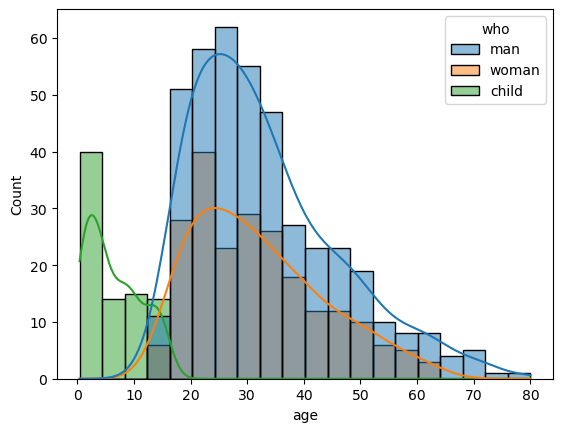

In [8]:
# graphical Method

sns.histplot(df, x='age',hue='who', kde=True)


## shapiro wilk test on normal distribution 

### Null Hypothesis : The data is normally distributed
### Alternative Hypothesis : the data is not normal

In [9]:
# shapiro wilk Test
statistics, p = stats.shapiro(df['age'])

if p > 0.05:
    print(f'p-value: {p}, Sample looks Gaussian/Normally Distribution (fail to reject H0)')
else:
    print(f'p-value: {p}, Sample does not looks Gaussian/Normally Distribution (reject H0)')

p-value: nan, Sample does not looks Gaussian/Normally Distribution (reject H0)


In [10]:
# shapiro wilk Test
statistics, p = stats.shapiro(df['fare'])

if p > 0.05:
    print(f'p-value: {p}, Sample looks Gaussian/Normally Distribution (fail to reject H0)')
else:
    print(f'p-value: {p}, Sample does not looks Gaussian/Normally Distribution (reject H0)')

p-value: 1.0840444395829658e-43, Sample does not looks Gaussian/Normally Distribution (reject H0)


# 3.t-test

## A. One-sample T-test

In [11]:
import scipy.stats as stats

In [12]:
# sample data
x = [1,2,3,4,5]

#  know population mean
mu = 4

# perform one sample t-test
t_statistics, p = stats.ttest_1samp(x,mu)

print('t_statistics:', t_statistics)
print('p-value:', p)

if p > 0.05:
    print(f'p-value: {p}, Sample mean is equal to population mean (fail to reject H0)')
else:
    print(f'p-value: {p},Sample mean is equal to population mean (reject H0)')

t_statistics: -1.414213562373095
p-value: 0.2301996410804989
p-value: 0.2301996410804989, Sample mean is equal to population mean (fail to reject H0)
